# Isolation Forest | Anomaly Detection

Isolation Forest builds an ensemble of random trees that isolate points by recursively partitioning the feature space. Anomalies require fewer splits to isolate => shorter average path length => lower (more negative) anomaly score.

Two approaches:
- **Phase 1 Global IF**: fit on all 1,500 paintings (50 PCA dims), then stratify results by artist to see which artists contribute the most anomalies
- **Phase 2 Per-Artist IF**: fit a separate IF on each qualified artist's embeddings, reduced to 10 PCA dims to compensate for small sample sizes

Both approaches use `contamination=0.05` (top 5% flagged) for consistency with cosine, Wasserstein, and KS results.

**Prerequisite:** Run `src/reduce_embeddings.py` and all three prior analysis notebooks before the cross-method section.

In [ ]:
# ╔════════════════════════════════════════════════════════════════════╗
# ║  DATASET CONFIGURATION                                             ║
# ║  Change these two lines to run on a different genre or dataset.    ║
# ║  Use 'clean' for exploration, 'injected' for AUC-ROC evaluation.   ║
# ╚════════════════════════════════════════════════════════════════════╝
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..') / 'src'))
from config import (
    CONTAMINATION, RANDOM_STATE, MIN_ARTIST_IMAGES,
    IF_N_ESTIMATORS, IF_N_ARTIST_DIMS,
    genre_dataset_dir, genre_results_dir,
)

GENRE        = 'impressionism'          # label used in plot titles and result filenames
DATASET_TYPE = 'injected'               # 'clean' or 'injected'

EMBEDDINGS_DIR = genre_dataset_dir(GENRE, DATASET_TYPE)
METADATA_PATH  = EMBEDDINGS_DIR / 'metadata.csv'
PCA_EMB_PATH   = EMBEDDINGS_DIR / 'embeddings_pca50.npy'
RESULTS_DIR    = genre_results_dir(GENRE, DATASET_TYPE)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Genre        : {GENRE}')
print(f'Dataset type : {DATASET_TYPE}')
print(f'Embeddings   : {PCA_EMB_PATH}')
print(f'Results dir  : {RESULTS_DIR}')

Genre        : impressionism
Dataset type : injected
Embeddings   : ..\embeddings\impressionism\injected\embeddings_pca50.npy
Results dir  : ..\results\impressionism\injected


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

# Load — paths come from config cell above
if not PCA_EMB_PATH.exists():
    raise FileNotFoundError(
    f'PCA embeddings not found: {PCA_EMB_PATH}\n'
    'Run: python src/reduce_embeddings.py --output_dir embeddings/clean'
)

embeddings_pca = np.load(PCA_EMB_PATH)
metadata       = pd.read_csv(METADATA_PATH).reset_index(drop=True)

print('PCA embeddings shape :', embeddings_pca.shape)
print('Metadata shape       :', metadata.shape)
if 'is_anomaly' in metadata.columns:
    print('Known anomalies      :', metadata['is_anomaly'].sum())

PCA embeddings shape : (1575, 50)
Metadata shape       : (1575, 14)
Known anomalies      : 75


## Phase 1: Global Isolation Forest

We fit one IF on all 1,500 paintings. `decision_function` returns a score per painting:
- More negative =? further from the bulk => more anomalous
- We invert the sign so higher = more anomalous (consistent with other methods)

In [ ]:
print('Fitting Global Isolation Forest...')
iso_global = IsolationForest(
    n_estimators=IF_N_ESTIMATORS,
    contamination=CONTAMINATION,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso_global.fit(embeddings_pca)

# decision_function: more negative = more anomalous in sklearn convention
# Negate so that higher = more anomalous (consistent with other methods)
global_if_scores = -iso_global.decision_function(embeddings_pca)
global_if_labels =  iso_global.predict(embeddings_pca)  # +1 = normal, -1 = anomaly

# Store in metadata
metadata['if_global_score'] = global_if_scores
metadata['if_global_norm']  = (
    (global_if_scores - global_if_scores.min()) /
    (global_if_scores.max() - global_if_scores.min())
)
metadata['if_global_flag'] = (global_if_labels == -1)

n_flagged = (global_if_labels == -1).sum()
print(f'Done. Flagged {n_flagged} / {len(metadata)} paintings as anomalies ({n_flagged/len(metadata):.1%})')
print(f'Score range: [{global_if_scores.min():.4f}, {global_if_scores.max():.4f}]')

Fitting Global Isolation Forest...
Flagged as anomalies : 79 / 1575 (5.0%)
Score mean : -0.0348
Score std  : 0.0192
Score min  : -0.0773
Score max  : 0.0535


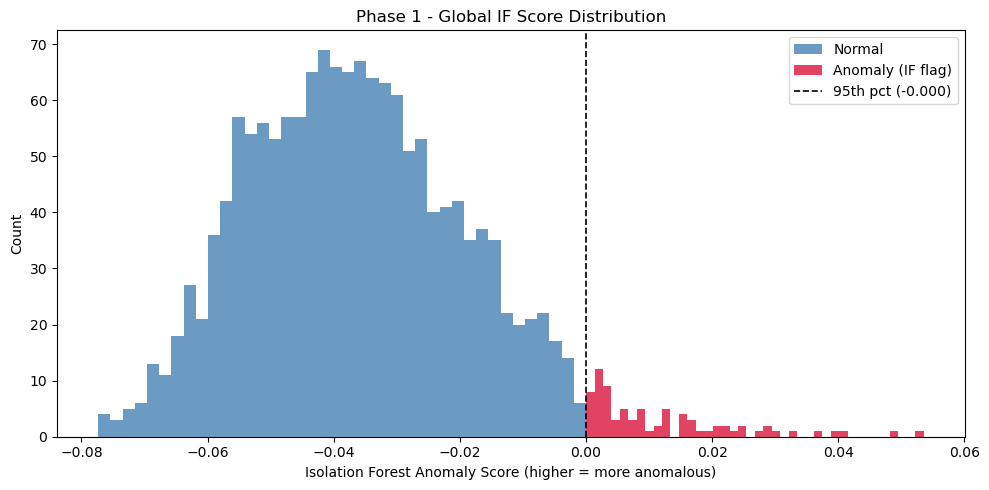

In [101]:
# Histogram of global IF scores
threshold = np.percentile(global_if_scores, 95)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(global_if_scores[global_if_labels == 1],  bins=40,
        color='steelblue', alpha=0.8, label='Normal')
ax.hist(global_if_scores[global_if_labels == -1], bins=40,
        color='crimson',   alpha=0.8, label='Anomaly (IF flag)')
ax.axvline(threshold, color='black', linestyle='--', linewidth=1.2,
           label=f'95th pct ({threshold:.3f})')
ax.set_xlabel('Isolation Forest Anomaly Score (higher = more anomalous)')
ax.set_ylabel('Count')
ax.set_title('Phase 1 - Global IF Score Distribution')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'if_phase1_global_histogram.png', dpi=150)
plt.show()

c:\Users\Yeva\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


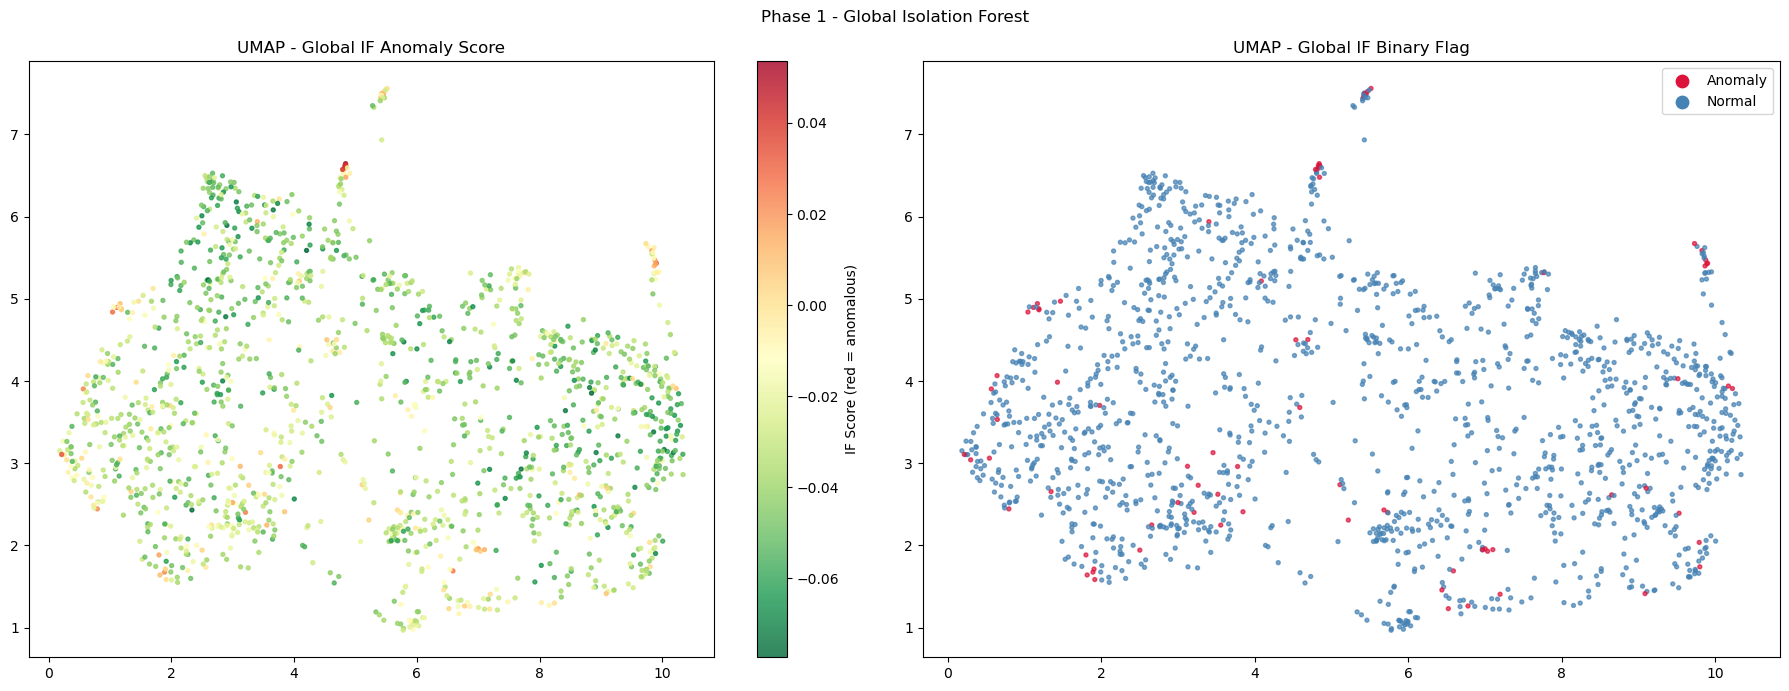

In [102]:
# UMAP coloured by global IF score
try:
    import umap
except ImportError:
    raise ImportError('Install umap-learn: pip install umap-learn')

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
coords  = reducer.fit_transform(embeddings_pca)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sc = axes[0].scatter(coords[:, 0], coords[:, 1],
                     c=global_if_scores, cmap='RdYlGn_r', s=8, alpha=0.8)
plt.colorbar(sc, ax=axes[0], label='IF Score (red = anomalous)')
axes[0].set_title('UMAP - Global IF Anomaly Score')

colors = np.where(global_if_labels == -1, 'crimson', 'steelblue')
axes[1].scatter(coords[:, 0], coords[:, 1], c=colors, s=8, alpha=0.7)
axes[1].scatter([], [], c='crimson',   s=20, label='Anomaly')
axes[1].scatter([], [], c='steelblue', s=20, label='Normal')
axes[1].legend(markerscale=2)
axes[1].set_title('UMAP - Global IF Binary Flag')

plt.suptitle('Phase 1 - Global Isolation Forest', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'if_phase1_global_umap.png', dpi=150)
plt.show()

In [103]:
# Top 20 anomalies (global IF)
top20_global = (
    metadata[['filename', 'artist', 'if_global_score', 'if_global_norm']]
    .sort_values('if_global_score', ascending=False)
    .head(20)
    .reset_index(drop=True)
)
print('Top 20 anomalies - Global IF:')
print(top20_global.to_string(index=False))

Top 20 anomalies - Global IF:
                                                                 filename                  artist  if_global_score  if_global_norm
      Impressionism/eugene-boudin_trouville-the-port-at-low-tide-1887.jpg           eugene boudin         0.053518        1.000000
                           Impressionism/claude-monet_boats-on-rapair.jpg            claude monet         0.049361        0.968230
                           Impressionism/claude-monet_ships-in-harbor.jpg            claude monet         0.041463        0.907862
               Impressionism/claude-monet_gestrandetes-boot-in-fecamp.jpg            claude monet         0.039688        0.894300
                    Impressionism/edgar-degas_manet-at-the-races-1870.jpg             edgar degas         0.036827        0.872432
                          Impressionism/t.-c.-steele_beech-trees-1895.jpg            t. c. steele         0.032410        0.838670
                    Impressionism/eugene-boudin_the-p

### Artist Stratification

We break down global IF anomalies by artist to see which artists contribute the most flagged paintings, and which artists have the highest anomaly *rate* (anomalies as % of their total paintings).

In [ ]:
artist_counts     = metadata['artist'].value_counts()
qualified_artists = artist_counts[artist_counts >= MIN_ARTIST_IMAGES].index.tolist()

meta_qualified = metadata[metadata['artist'].isin(qualified_artists)].copy()

stratification = (
    meta_qualified.groupby('artist')
    .agg(
        n_total      =('if_global_flag', 'count'),
        n_anomalies  =('if_global_flag', 'sum'),
        mean_score   =('if_global_score', 'mean'),
        max_score    =('if_global_score', 'max')
    )
    .reset_index()
)
stratification['anomaly_rate'] = stratification['n_anomalies'] / stratification['n_total']
stratification = stratification.sort_values('anomaly_rate', ascending=False).reset_index(drop=True)
print(stratification.to_string(index=False))

               artist  n_total  n_anomalies  mean_score  max_score  anomaly_rate
        eugene boudin       59            6   -0.031025   0.053518      0.101695
         claude monet      169           16   -0.030644   0.049361      0.094675
  john singer sargent       33            3   -0.028047   0.012644      0.090909
   konstantin korovin       26            2   -0.030020   0.003985      0.076923
     joaquã­n sorolla       39            2   -0.030864   0.015513      0.051282
          edgar degas       64            3   -0.044343   0.036827      0.046875
william merritt chase       43            2   -0.034370   0.008427      0.046512
  gustave caillebotte       24            1   -0.028727   0.002513      0.041667
     camille pissarro       91            3   -0.040081   0.017695      0.032967
pierre auguste renoir      165            5   -0.039238   0.022428      0.030303
        childe hassam       59            1   -0.036567   0.012610      0.016949
        alfred sisley       

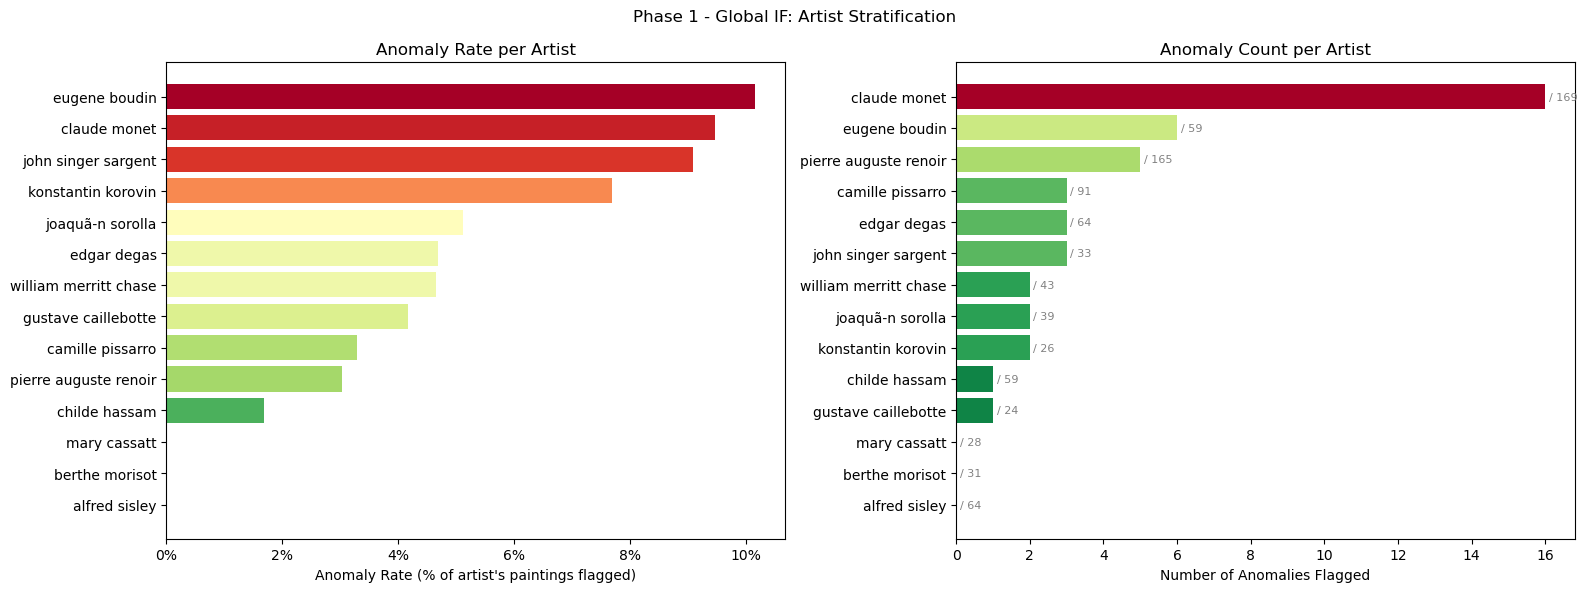

In [105]:
# Artist stratification: count + rate side by side 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
strat_sorted_rate  = stratification.sort_values('anomaly_rate')
strat_sorted_count = stratification.sort_values('n_anomalies')

# anomaly rate
rate_colors = plt.cm.RdYlGn_r(
    (strat_sorted_rate['anomaly_rate'] - strat_sorted_rate['anomaly_rate'].min()) /
    (strat_sorted_rate['anomaly_rate'].max() - strat_sorted_rate['anomaly_rate'].min() + 1e-9)
)
axes[0].barh(strat_sorted_rate['artist'], strat_sorted_rate['anomaly_rate'],
             color=rate_colors)
axes[0].set_xlabel('Anomaly Rate (% of artist\'s paintings flagged)')
axes[0].set_title('Anomaly Rate per Artist')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# anomaly count
count_colors = plt.cm.RdYlGn_r(
    (strat_sorted_count['n_anomalies'] - strat_sorted_count['n_anomalies'].min()) /
    (strat_sorted_count['n_anomalies'].max() - strat_sorted_count['n_anomalies'].min() + 1e-9)
)
bars = axes[1].barh(strat_sorted_count['artist'], strat_sorted_count['n_anomalies'],
                    color=count_colors)
for bar, total in zip(bars, strat_sorted_count['n_total']):
    axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                 f'/ {int(total)}', va='center', fontsize=8, color='gray')
axes[1].set_xlabel('Number of Anomalies Flagged')
axes[1].set_title('Anomaly Count per Artist')

plt.suptitle('Phase 1 - Global IF: Artist Stratification', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'if_phase1_artist_stratification.png', dpi=150)
plt.show()

C:\Users\Yeva\AppData\Local\Temp\ipykernel_7704\2752751967.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=artist_order, patch_artist=True, vert=True)


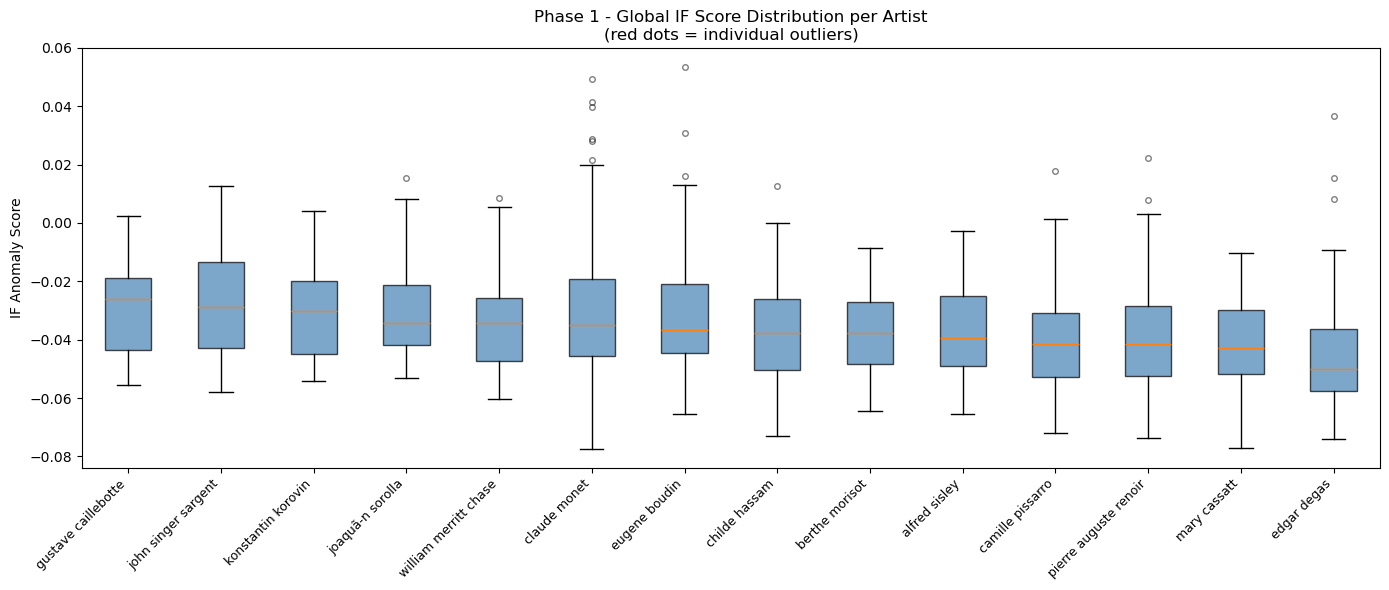

In [106]:
# Score distribution per artist (box plot) 
artist_order = (
    meta_qualified.groupby('artist')['if_global_score']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)
data_to_plot = [
    meta_qualified[meta_qualified['artist'] == a]['if_global_score'].values
    for a in artist_order
]

fig, ax = plt.subplots(figsize=(14, 6))
bp = ax.boxplot(data_to_plot, labels=artist_order, patch_artist=True, vert=True)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
for flier in bp['fliers']:
    flier.set(marker='o', color='crimson', alpha=0.5, markersize=4)
ax.set_xticklabels(artist_order, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('IF Anomaly Score')
ax.set_title('Phase 1 - Global IF Score Distribution per Artist\n'
             '(red dots = individual outliers)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'if_phase1_artist_boxplot.png', dpi=150)
plt.show()

In [107]:
# Save Phase 1
metadata[['filename', 'artist', 'if_global_score', 'if_global_norm', 'if_global_flag']].to_csv(
    RESULTS_DIR / 'if_phase1_global_scores.csv', index=False
)
print('Saved - results/if_phase1_global_scores.csv')

Saved - results/if_phase1_global_scores.csv


## Phase 2: Per-Artist Isolation Forest (Reduced Dims)

We fit a separate IF on each qualified artist's embeddings, reduced to **10 PCA dimensions**.
This catches paintings that are outliers *within their own artist's style*, even if they're not unusual at the global genre level.

In [ ]:
artist_if_scores  = np.full(len(metadata), np.nan)
artist_if_flags   = np.zeros(len(metadata), dtype=bool)

for artist in qualified_artists:
    idx        = metadata[metadata['artist'] == artist].index.tolist()
    artist_emb = embeddings_pca[idx]
    n_samples  = len(idx)

    # fit per-artist PCA
    n_dims = min(IF_N_ARTIST_DIMS, n_samples - 1)
    pca_artist = PCA(n_components=n_dims, random_state=RANDOM_STATE)
    artist_emb_reduced = pca_artist.fit_transform(artist_emb)

    # fit per-artist IF
    iso_artist = IsolationForest(
        n_estimators=IF_N_ESTIMATORS,
        contamination=CONTAMINATION,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    iso_artist.fit(artist_emb_reduced)

    scores = -iso_artist.decision_function(artist_emb_reduced)
    labels =  iso_artist.predict(artist_emb_reduced)

    for local_i, global_i in enumerate(idx):
        artist_if_scores[global_i] = scores[local_i]
        artist_if_flags[global_i]  = (labels[local_i] == -1)

    n_flagged = (labels == -1).sum()
    print(f'{artist:<30} n={n_samples:>3}  dims={n_dims}  flagged={n_flagged}')

metadata['if_artist_score'] = artist_if_scores
metadata['if_artist_flag']  = artist_if_flags

claude monet                   n=169  dims=10  flagged=9
pierre auguste renoir          n=165  dims=10  flagged=9
camille pissarro               n= 91  dims=10  flagged=5
edgar degas                    n= 64  dims=10  flagged=4
alfred sisley                  n= 64  dims=10  flagged=4
eugene boudin                  n= 59  dims=10  flagged=3
childe hassam                  n= 59  dims=10  flagged=3
william merritt chase          n= 43  dims=10  flagged=3
joaquã­n sorolla               n= 39  dims=10  flagged=2
john singer sargent            n= 33  dims=10  flagged=2
berthe morisot                 n= 31  dims=10  flagged=2
mary cassatt                   n= 28  dims=10  flagged=2
konstantin korovin             n= 26  dims=10  flagged=2
gustave caillebotte            n= 24  dims=10  flagged=2


C:\Users\Yeva\AppData\Local\Temp\ipykernel_7704\759309978.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data2, labels=artist_order2, patch_artist=True)


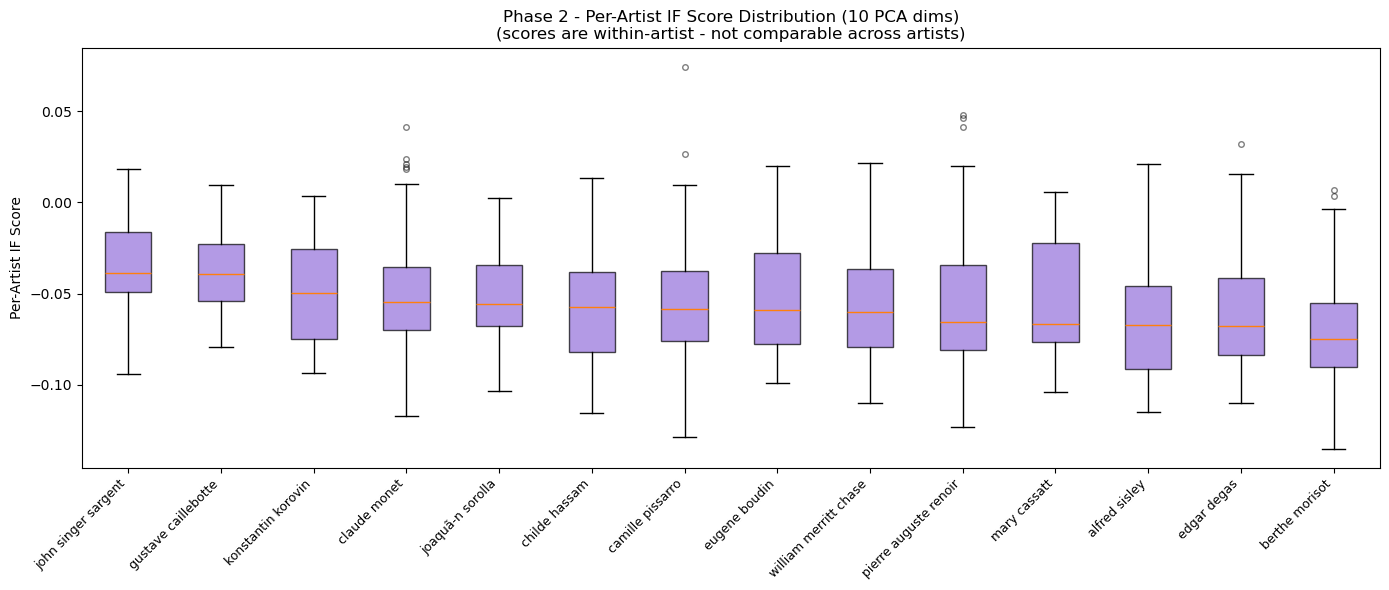

In [109]:
# Per-artist IF: score distribution (box plot)
meta_qualified = metadata[metadata['artist'].isin(qualified_artists)].copy()

artist_order2 = (
    meta_qualified.groupby('artist')['if_artist_score']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)
data2 = [
    meta_qualified[meta_qualified['artist'] == a]['if_artist_score'].values
    for a in artist_order2
]

fig, ax = plt.subplots(figsize=(14, 6))
bp = ax.boxplot(data2, labels=artist_order2, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('mediumpurple')
    patch.set_alpha(0.7)
for flier in bp['fliers']:
    flier.set(marker='o', color='crimson', alpha=0.5, markersize=4)
ax.set_xticklabels(artist_order2, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Per-Artist IF Score')
ax.set_title('Phase 2 - Per-Artist IF Score Distribution (10 PCA dims)\n'
             '(scores are within-artist - not comparable across artists)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'if_phase2_artist_boxplot.png', dpi=150)
plt.show()

In [110]:
# Top anomaly per artist (Phase 2)
top_per_artist = (
    meta_qualified
    .sort_values('if_artist_score', ascending=False)
    .groupby('artist')
    .first()
    [['filename', 'if_artist_score', 'if_global_score']]
    .sort_values('if_artist_score', ascending=False)
    .reset_index()
)
print('Worst outlier per artist (Phase 2 per-artist IF):')
print(top_per_artist.to_string(index=False))

Worst outlier per artist (Phase 2 per-artist IF):
               artist                                                                          filename  if_artist_score  if_global_score
     camille pissarro                      Impressionism/camille-pissarro_peasant-woman-at-the-well.jpg         0.074273         0.017695
pierre auguste renoir                  Impressionism/pierre-auguste-renoir_woman-at-the-garden-1873.jpg         0.047687        -0.009614
         claude monet                                    Impressionism/claude-monet_ships-in-harbor.jpg         0.041179         0.041463
          edgar degas                           Impressionism/edgar-degas_at-saint-valery-sur-somme.jpg         0.032255        -0.041750
william merritt chase                                  Impressionism/william-merritt-chase_seascape.jpg         0.021690         0.008427
        alfred sisley                         Impressionism/alfred-sisley_snow-at-louveciennes-1878.jpg         0.021185  

In [111]:
# Phase 1 vs Phase 2 
both_flagged = meta_qualified[
    meta_qualified['if_global_flag'] & meta_qualified['if_artist_flag']
][['filename', 'artist', 'if_global_score', 'if_artist_score']].sort_values(
    'if_global_score', ascending=False
).reset_index(drop=True)

print(f'Flagged by BOTH global and per-artist IF: {len(both_flagged)} paintings')
print(both_flagged.to_string(index=False))

Flagged by BOTH global and per-artist IF: 15 paintings
                                                                         filename                artist  if_global_score  if_artist_score
                                   Impressionism/claude-monet_boats-on-rapair.jpg          claude monet         0.049361         0.010112
                                   Impressionism/claude-monet_ships-in-harbor.jpg          claude monet         0.041463         0.041179
                       Impressionism/claude-monet_gestrandetes-boot-in-fecamp.jpg          claude monet         0.039688         0.020774
                            Impressionism/edgar-degas_manet-at-the-races-1870.jpg           edgar degas         0.036827         0.006843
                                   Impressionism/claude-monet_the-magpie-1869.jpg          claude monet         0.028638         0.023909
                                    Impressionism/claude-monet_boats-at-rouen.jpg          claude monet         0.019

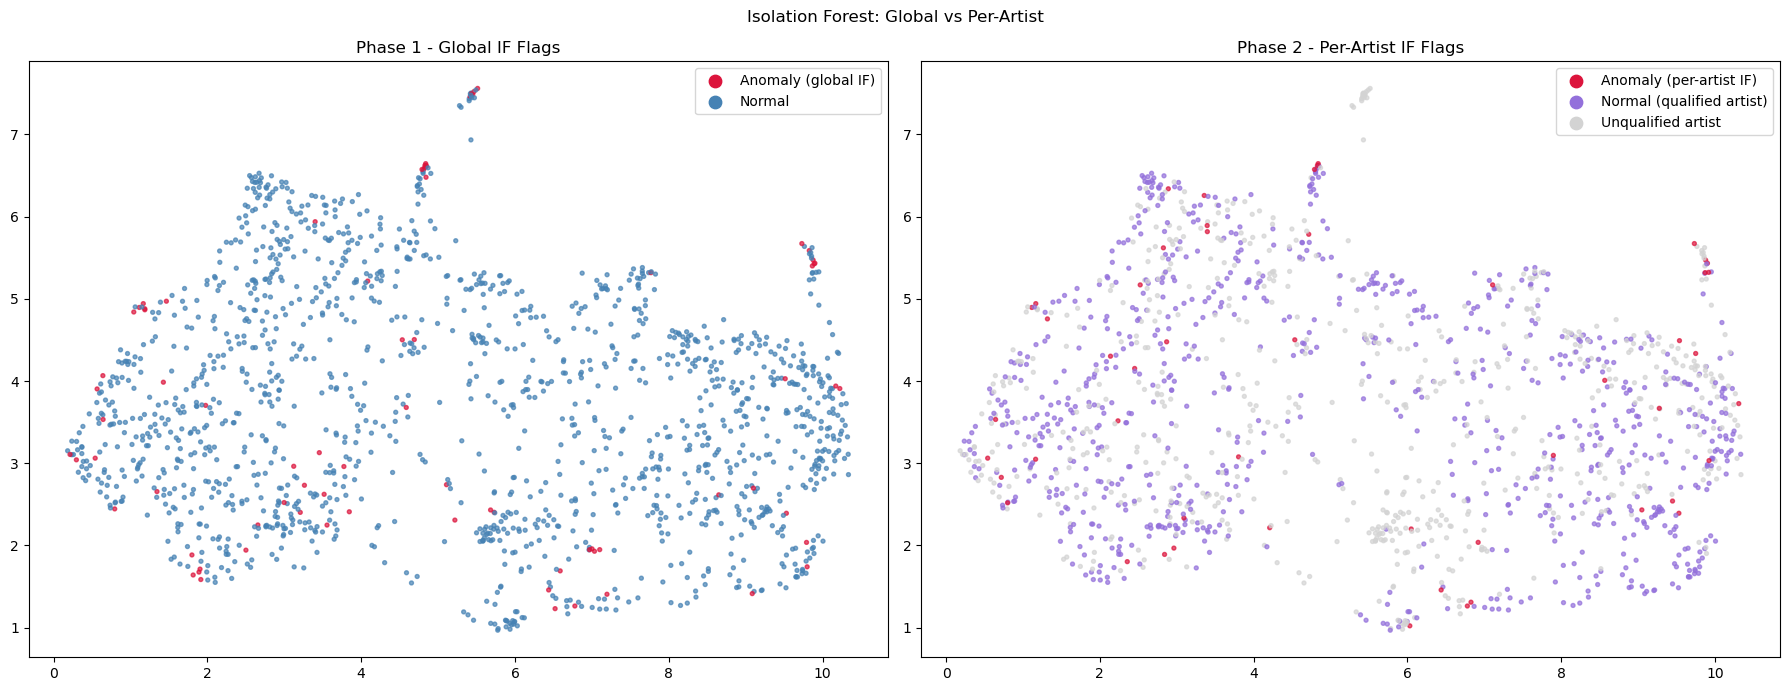

In [112]:
# UMAP: Phase 1 vs Phase 2
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Global IF
colors_global = np.where(metadata['if_global_flag'], 'crimson', 'steelblue')
axes[0].scatter(coords[:, 0], coords[:, 1], c=colors_global, s=8, alpha=0.7)
axes[0].scatter([], [], c='crimson',   s=20, label='Anomaly (global IF)')
axes[0].scatter([], [], c='steelblue', s=20, label='Normal')
axes[0].legend(markerscale=2)
axes[0].set_title('Phase 1 - Global IF Flags')

# Per-artist IF
colors_artist = np.where(
    metadata['if_artist_flag'].fillna(False), 'crimson',
    np.where(metadata['if_artist_score'].isna(), 'lightgrey', 'mediumpurple')
)
axes[1].scatter(coords[:, 0], coords[:, 1], c=colors_artist, s=8, alpha=0.7)
axes[1].scatter([], [], c='crimson',     s=20, label='Anomaly (per-artist IF)')
axes[1].scatter([], [], c='mediumpurple',s=20, label='Normal (qualified artist)')
axes[1].scatter([], [], c='lightgrey',   s=20, label='Unqualified artist')
axes[1].legend(markerscale=2)
axes[1].set_title('Phase 2 - Per-Artist IF Flags')

plt.suptitle('Isolation Forest: Global vs Per-Artist', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'if_phase1_vs_phase2_umap.png', dpi=150)
plt.show()

In [113]:
# Save Phase 2
metadata[['filename', 'artist', 'if_artist_score', 'if_artist_flag']].to_csv(
    RESULTS_DIR / 'if_phase2_artist_scores.csv', index=False
)
print('Saved - results/if_phase2_artist_scores.csv')

Saved - results/if_phase2_artist_scores.csv


## Cross-Method Comparison: All 4 Methods

Combines Cosine Similarity, Wasserstein, KS Test, and Isolation Forest.
Paintings flagged by all 4 are the most confident anomaly candidates in the dataset.

In [114]:
cosine_path = RESULTS_DIR / 'phase1_global_cosine_scores.csv'
swd_path    = RESULTS_DIR / 'wasserstein_phase2_painting_scores.csv'
ks_path     = RESULTS_DIR / 'ks_phase2_painting_scores.csv'

missing = [p for p in [cosine_path, swd_path, ks_path] if not p.exists()]
if missing:
    print('Missing result files - run these notebooks first:')
    for p in missing:
        print(f'  {p.name}')
else:
    cosine_df = pd.read_csv(cosine_path)[['filename', 'global_anomaly_score']]
    swd_df    = pd.read_csv(swd_path)[['filename', 'painting_swd_norm']]
    ks_df     = pd.read_csv(ks_path)[['filename', 'ks_mean_d']]
    if_df     = metadata[['filename', 'artist', 'if_global_norm']]

    # normalize KS 0-1
    ks_df = ks_df.copy()
    ks_df['ks_norm'] = (
        (ks_df['ks_mean_d'] - ks_df['ks_mean_d'].min()) /
        (ks_df['ks_mean_d'].max() - ks_df['ks_mean_d'].min())
    )

    all4 = (
        if_df
        .merge(cosine_df, on='filename', how='inner')
        .merge(swd_df,    on='filename', how='inner')
        .merge(ks_df[['filename', 'ks_norm']], on='filename', how='inner')
    )

    # top 5% per method
    all4['flag_cosine'] = all4['global_anomaly_score'] >= np.percentile(all4['global_anomaly_score'], 95)
    all4['flag_swd']    = all4['painting_swd_norm']    >= np.percentile(all4['painting_swd_norm'],    95)
    all4['flag_ks']     = all4['ks_norm']              >= np.percentile(all4['ks_norm'],              95)
    all4['flag_if']     = all4['if_global_norm']       >= np.percentile(all4['if_global_norm'],       95)
    all4['n_methods']   = (
        all4['flag_cosine'].astype(int) + all4['flag_swd'].astype(int) +
        all4['flag_ks'].astype(int)     + all4['flag_if'].astype(int)
    )

    print('Flagged by N methods:')
    print(all4['n_methods'].value_counts().sort_index().to_string())

Flagged by N methods:
n_methods
0    1346
1     155
2      63
3       9
4       2


In [115]:
if 'all4' in dir():
    # Flagged by ALL 4 
    consensus4 = (
        all4[all4['n_methods'] == 4]
        [['filename', 'artist', 'global_anomaly_score', 'painting_swd_norm',
          'ks_norm', 'if_global_norm']]
        .sort_values('if_global_norm', ascending=False)
        .reset_index(drop=True)
    )
    print(f'Flagged by ALL 4 methods ({len(consensus4)} paintings):')
    print(consensus4.to_string(index=False))

    # Flagged by exactly 3 methods 
    three_method_combos = {
        'Cosine + SWD + KS (not IF)' : all4['flag_cosine'] & all4['flag_swd']  & all4['flag_ks']  & ~all4['flag_if'],
        'Cosine + SWD + IF (not KS)' : all4['flag_cosine'] & all4['flag_swd']  & all4['flag_if']  & ~all4['flag_ks'],
        'Cosine + KS  + IF (not SWD)': all4['flag_cosine'] & all4['flag_ks']   & all4['flag_if']  & ~all4['flag_swd'],
        'SWD   + KS  + IF (not Cos)' : all4['flag_swd']    & all4['flag_ks']   & all4['flag_if']  & ~all4['flag_cosine'],
    }
    print()
    for label, mask in three_method_combos.items():
        subset = all4[mask][['filename', 'artist', 'global_anomaly_score',
                              'painting_swd_norm', 'ks_norm', 'if_global_norm']]
        print(f'{label} - {len(subset)} paintings:')
        if len(subset) > 0:
            print(subset.sort_values('if_global_norm', ascending=False).to_string(index=False))
        print()

Flagged by ALL 4 methods (2 paintings):
                                                  filename        artist  global_anomaly_score  painting_swd_norm  ks_norm  if_global_norm
Impressionism/claude-monet_gestrandetes-boot-in-fecamp.jpg  claude monet              0.614898           0.826847 0.927213        0.894300
     Impressionism/eugene-boudin_the-port-at-deauville.jpg eugene boudin              0.619024           0.803344 0.895455        0.825453

Cosine + SWD + KS (not IF) - 0 paintings:

Cosine + SWD + IF (not KS) - 0 paintings:

Cosine + KS  + IF (not SWD) - 4 paintings:
                                                             filename                 artist  global_anomaly_score  painting_swd_norm  ks_norm  if_global_norm
                       Impressionism/claude-monet_boats-on-rapair.jpg           claude monet              0.693592           0.720346 0.855067        0.968230
                       Impressionism/claude-monet_ships-in-harbor.jpg           claude monet   

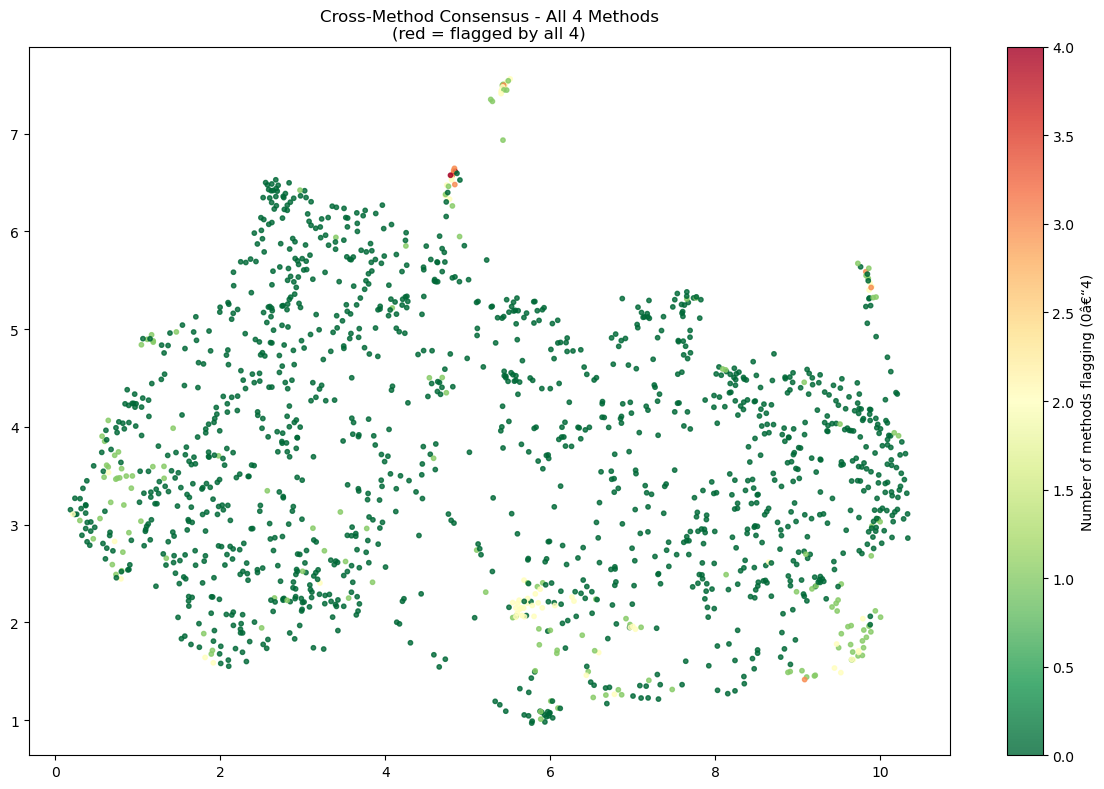

Saved - results/cross_method_all4_scores.csv

All done. Four methods complete: Cosine / Wasserstein / KS / Isolation Forest.


In [116]:
if 'all4' in dir():
    # UMAP coloured by number of agreeing methods
    fig, ax = plt.subplots(figsize=(12, 8))
    sc = ax.scatter(coords[:, 0], coords[:, 1],
                    c=all4['n_methods'], cmap='RdYlGn_r',
                    vmin=0, vmax=4, s=10, alpha=0.8)
    plt.colorbar(sc, ax=ax, label='Number of methods flagging (0â€“4)')
    ax.set_title('Cross-Method Consensus - All 4 Methods\n'
                 '(red = flagged by all 4)')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'if_cross_method_consensus_umap.png', dpi=150)
    plt.show()

    # Save full 4-method scores
    all4.to_csv(RESULTS_DIR / 'cross_method_all4_scores.csv', index=False)
    print('Saved - results/cross_method_all4_scores.csv')
    print()
    print('All done. Four methods complete: Cosine / Wasserstein / KS / Isolation Forest.')